# 01 – The Data
**Can a synthetic dataset be used instead of the original employee feedback?**

This notebook prepares the dataset used throughout the ELFI project.

The analysis is based on a synthetic employee feedback dataset created to mimic the structure and characteristics of real survey data while protecting privacy and confidentiality. In this notebook, the raw data is loaded, inspected, and enriched with quality indicators that help identify potential response issues without removing any records.

The resulting dataset serves as the foundation for the analyses presented in the following notebooks.

---

## Step 1 — What the survey is

The employee survey is run repeatedly across the organisation. Each response contains:

* **54 closed items** on a five-point agreement scale, from *"Stimme gar nicht zu"*
  to *"Stimme voll und ganz zu"*, plus a *"Kann ich nicht beurteilen"* option that
  is not a position on the scale and is therefore treated as missing
* **one free-text comment**, optional — this is what the whole project is about
* **context**: which area the respondent works in, which survey wave and run, when
  they started and finished

51 of the 54 items are grouped into eight thematic dimensions. The remaining three sit
outside those dimensions but still count towards the overall score. The grouping was
created during this project and does not correspond to the groupings from the
organization.

In [1]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Specifies how wide the output in the notebook may be.
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 80)

# create operating system-independent file paths with Path from pathlib 
DATA = Path("../synthetic_dataset")

# ---- which dataset ----------------------------------------------------------
# "synthetic" is the shareable stand-in; "real" is the original survey. The whole
# chain follows this one value — every notebook in the set has the same switch.
SOURCE = "synthetic"

if SOURCE == "synthetic":
    INPUT = DATA / "synthetic" / "synthetic_data_transformed.csv"
    WORK = DATA / "synthetic"
elif SOURCE == "real":
    INPUT = DATA / "processed" / "real_transformed.csv"
    WORK = DATA / "results" / "real_run"
    # Automatically creates the folder.
    # Parameter: parents=True also creates missing parent folders.
    WORK.mkdir(parents=True, exist_ok=True)
    print("!" * 70)
    print("SOURCE = 'real'. The outputs of this run, and the outputs stored inside")
    print("this notebook's cells, contain real employee comments. Do not commit or")
    print("share the executed copy — keep it out of the shareable notebook folder.")
    print("!" * 70 + "\n")
else:
    raise ValueError("SOURCE must be 'synthetic' or 'real'")

OUTPUT = WORK / f"{SOURCE}_clean.parquet"

# ---- palette, shared across all six notebooks -------------------------------
BLUE, BLUE_SOFT = "#2a78d6", "#9ec5f4"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"
GRID, BASELINE = "#e6e5e0", "#c3c2b7"

# global plot theme
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "legend.frameon": False,
})

In [2]:
# ============================================================
# Load
# ============================================================

raw = pd.read_csv(INPUT, sep=";", encoding="utf-8-sig", low_memory=False)

print(f"{len(raw):,} responses, {len(raw.columns)} columns\n")
print("How the answers arrive — as text, not numbers:")
print(raw[["arbeitsfreude", "teamstimmung", "ueberlastung"]].head(4).to_string(index=False))

5,000 responses, 66 columns

How the answers arrive — as text, not numbers:
      arbeitsfreude            teamstimmung            ueberlastung
Stimme gar nicht zu   Stimme eher nicht zu  Stimme voll und ganz zu
    Stimme eher zu          Stimme eher zu     Stimme eher nicht zu
    Stimme eher zu  Stimme voll und ganz zu             Teils/Teils
        Teils/Teils             Teils/Teils             Teils/Teils


## Step 2 — Data Cleaning and Quality Signals

Before any analysis can begin, the survey data is transformed into an analysis-ready format and enriched with quality indicators.

### Data Preparation

Survey responses are converted from text labels to numerical values on a 1–5 scale. The response *"Cannot assess"* is treated as missing because it reflects the absence of an evaluation rather than a neutral position.

One overload item is reverse-coded so that higher values consistently represent more favorable outcomes across all questions.

To support later analyses, 51 of the 54 survey items are aggregated into eight thematic dimensions; three items remain ungrouped. In addition, an `overall_score` is calculated as the mean across all 54 survey items and serves as the primary summary measure used throughout the project.

### Data Quality Signals

Three indicators are calculated for each respondent:

* **`duration_minutes`** – survey completion time
* **`n_no_judgement`** – number of unanswered or *"Cannot assess"* responses
* **`answer_std`** – response variability across survey items

These metrics are used to generate two quality flags:

* **`flag_speeder`** – unusually short completion time (bottom 5% of the sample)
* **`flag_straightliner`** – very low response variability (`answer_std < 0.3`)

A third flag, **`quality_flag`**, is set only when both conditions occur simultaneously. This conservative approach focuses on respondents who are both exceptionally fast and show little variation in their answers.

### Interpretation

The quality flags are intended as indicators rather than automatic exclusion criteria. No records are removed from the dataset. Instead, the flags remain available so that later analyses can decide whether and how to account for potential response quality issues.

In [3]:
# ============================================================
# Clean
# ============================================================

LIKERT = {"Stimme gar nicht zu": 1, "Stimme eher nicht zu": 2, "Teils/Teils": 3,
          "Stimme eher zu": 4, "Stimme voll und ganz zu": 5}
NO_JUDGEMENT = "Kann ich nicht beurteilen"

#Creating the 8 groups
DIMENSIONS = {
    "teamarbeit": ["team_effizienz", "zusammenarbeit_team", "zusammenarbeit_schnittstellen",
                   "effizienz_schnittstellen", "hilfe_bitten", "teamstimmung"],
    "kultur": ["psychologische_sicherheit", "fehlerkultur_keine_vorwuerfe",
               "fehlerkultur_massnahmen", "meinungsfreiheit", "respekt",
               "kulturentwicklung_richtung"],
    "fuehrung": ["ehrlichkeit_fuehrung", "einbeziehung_fuehrung",
                 "veraenderung_vorantreiben", "rahmenbedingungen_change"],
    "strategie": ["businessentscheidungen_richtung", "strategie_einfluss",
                  "strategieklarheit", "zielbeitrag_strategie", "info_geschaeftslage",
                  "beitrag_wettbewerbsfaehigkeit"],
    "arbeitsgestaltung": ["gestaltungsspielraum", "eigenverantwortung_entscheidungen",
                          "entscheidungsgeschwindigkeit", "erwartungsklarheit",
                          "klare_ziele", "verantwortung_foerderung",
                          "einfluss_arbeitsmenge", "arbeitsinformationen"],
    "entwicklung": ["staerken_nutzen", "weiterentwicklung_foerderung",
                    "anforderung_faehigkeit_match", "feedback_nutzen", "neues_lernen",
                    "anspruchsvolle_aufgaben", "faehigkeiten_ausbau"],
    "wertschoepfung": ["produktgestaltung_aktiv", "kundenfokus", "beitrag_kundennutzen",
                       "prozessverbesserung_kontinuierlich", "prozesse_hinterfragen",
                       "externe_impulse", "tools_technologien",
                       "neue_ideen_ausprobieren", "veraenderung_aktiv"],
    "engagement": ["lob_anerkennung", "arbeitgeber_empfehlung", "arbeitsfreude",
                   "work_life_balance", "ueberlastung_r"],
}
UNGROUPED = ["info_fuehrung_veraenderung", "veraenderung_nachvollziehbar",
             "offene_kommunikation"]

# --- 1. rename ---------------------------------------------------------------
RENAME = {"ID": "id", "Startzeit": "start", "Fertigstellungszeit": "ende",
          "IterationID": "iteration_id", "RunID": "run_id",
          "AbteilungsID": "abteilungs_id"}
for column in raw.columns:
    if column.startswith("Ich arbeite bei"):
        RENAME[column] = "organisation"
    elif "Ich arbeite im Bereich" in column:
        RENAME[column] = "bereich"

data = raw.rename(columns=RENAME).drop(columns=[c for c in ("E-Mail", "Name")
                                                if c in raw.columns])

# --- 2. recode ---------------------------------------------------------------
def normalise(series):
    # the survey tool leaves non-breaking spaces on some labels
    return (series.astype("string").str.replace("\xa0", " ", regex=False)
            .str.replace(r"\s+", " ", regex=True).str.strip())


# A column is Likert only if virtually all of its answers are scale labels. Testing
# with .any() would sweep up the comment column too: in the real survey three of the
# comments happen to read exactly like a scale label, and mapping the column would
# then discard every comment that does not. The share separates the two cleanly —
# real Likert columns sit above 99.8 %, the comment column at 0.07 %.
def likert_share(series):
    text = normalise(series)
    answered = text.notna() & (text != "")
    if not answered.any():
        return 0.0
    return text[answered].isin(set(LIKERT) | {NO_JUDGEMENT}).mean()


likert_columns = [c for c in data.columns if data[c].dtype == object
                  and likert_share(data[c]) > 0.9]
refusals = 0
for column in likert_columns:
    text = normalise(data[column])
    refusals += (text == NO_JUDGEMENT).sum()
    data[column] = text.map(LIKERT)

# --- 3. reverse-code overload ------------------------------------------------
data["ueberlastung_r"] = 6 - data["ueberlastung"]

# --- 4. dimension scores -----------------------------------------------------
ITEMS = [i for items in DIMENSIONS.values() for i in items] + UNGROUPED
ITEMS = [i for i in ITEMS if i in data.columns]
for name, items in DIMENSIONS.items():
    data[f"{name}_score"] = data[[i for i in items if i in data.columns]].mean(axis=1)
data["overall_score"] = data[ITEMS].mean(axis=1)

# --- 5. area hierarchy -------------------------------------------------------
codes = data["bereich"].astype("string").str.strip()
data["bereich_clean"] = codes
data["bereich_ebene"] = codes.str.split(" ").str[0].str.split("-").str[:2].str.join("-")

# --- 6. quality signals ------------------------------------------------------
data["start"] = pd.to_datetime(data["start"], errors="coerce", dayfirst=True)
data["ende"] = pd.to_datetime(data["ende"], errors="coerce", dayfirst=True)
data["duration_minutes"] = (data["ende"] - data["start"]).dt.total_seconds() / 60
data["n_no_judgement"] = data[ITEMS].isna().sum(axis=1)
data["answer_std"] = data[ITEMS].std(axis=1)
data["flag_speeder"] = data["duration_minutes"] < data["duration_minutes"].quantile(0.05)
data["flag_straightliner"] = data["answer_std"] < 0.3
data["quality_flag"] = data["flag_speeder"] & data["flag_straightliner"]

# --- the comments ------------------------------------------------------------
data["freitext_kommentar"] = data["freitext_kommentar"].fillna("").astype(str).str.strip()
data["has_comment"] = (data["freitext_kommentar"] != "").astype(int)
data["word_count"] = np.where(data["has_comment"] == 1,
                              data["freitext_kommentar"].str.split().str.len(), np.nan)

print(f"recoded {len(likert_columns)} items")
print(f"'{NO_JUDGEMENT}' answers set to missing: {refusals:,}")
print(f"dimension scores built: {len(DIMENSIONS)} + overall")

recoded 54 items
'Kann ich nicht beurteilen' answers set to missing: 2,268
dimension scores built: 8 + overall


### What the two quality rules actually catch

The section above sets out a deliberately conservative rule: a response is only marked
as doubtful when it is *both* unusually fast *and* unusually uniform, and even then it
stays in the dataset. That is a decision worth seeing rather than reading.

Two pictures follow. The first counts what each rule catches, the second shows where
each cut falls in the distribution it is cutting through.

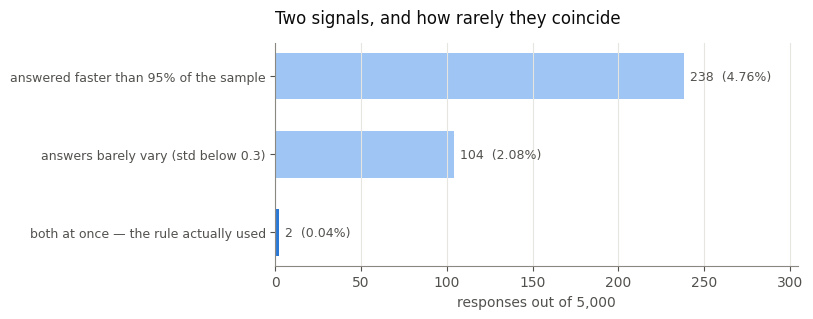

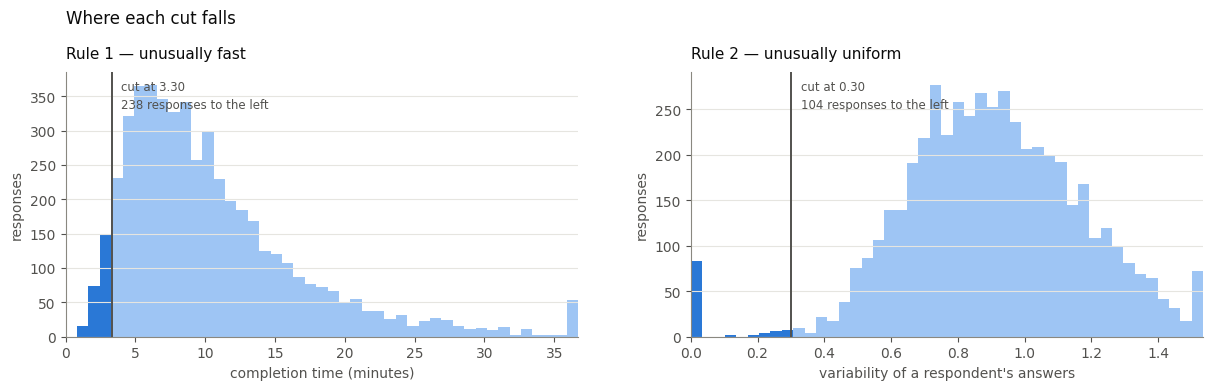

In [4]:
# ============================================================
# What the Quality Rules Catch
# ============================================================

RULES = [
    ("answered faster than 95% of the sample", data["flag_speeder"]),
    ("answers barely vary (std below 0.3)", data["flag_straightliner"]),
    ("both at once — the rule actually used", data["quality_flag"]),
]

labels = [caption for caption, _ in RULES]
counts = [int(flag.sum()) for _, flag in RULES]
positions = np.arange(len(RULES))

fig, ax = plt.subplots(figsize=(9.5, 3.6))
fig.subplots_adjust(left=0.42, right=0.97, top=0.82, bottom=0.20)

# the rule that is actually applied is the last one, and it is the one to look at
ax.barh(positions, counts, height=0.6,
        color=[BLUE_SOFT, BLUE_SOFT, BLUE])

for y, count in enumerate(counts):
    ax.text(count + max(counts) * 0.015, y, f"{count:,}  ({count / len(data):.2%})",
            va="center", color=INK_SOFT, fontsize=9)

ax.set_yticks(positions)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()                      # reads top to bottom, like the list above
ax.set_xlim(0, max(counts) * 1.28)
ax.grid(axis="y", visible=False)
ax.set_xlabel(f"responses out of {len(data):,}")
ax.set_title("Two signals, and how rarely they coincide", fontsize=12, loc="left",
             pad=14)

plt.show()


# ============================================================
# Where the Two Cuts Fall
# ============================================================

CUTS = [
    ("duration_minutes", data["duration_minutes"].quantile(0.05),
     "completion time (minutes)", "Rule 1 — unusually fast"),
    ("answer_std", 0.3,
     "variability of a respondent's answers", "Rule 2 — unusually uniform"),
]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
fig.subplots_adjust(left=0.07, right=0.98, top=0.80, bottom=0.17, wspace=0.22)

for ax, (column, cut, caption, heading) in zip(axes, CUTS):
    values = data[column].dropna()
    # a few respondents left the survey open for hours; the axis stops before them so
    # the bulk of the distribution stays readable
    ceiling = values.quantile(0.99)
    edges = np.linspace(0, ceiling, 46)
    ax.hist(values.clip(upper=ceiling), bins=edges, color=BLUE_SOFT)
    ax.hist(values[values < cut], bins=edges, color=BLUE)
    ax.axvline(cut, color=INK_SOFT, lw=1.4, zorder=3)

    caught = int((values < cut).sum())
    ax.annotate(f"cut at {cut:.2f}\n{caught:,} responses to the left",
                xy=(cut, ax.get_ylim()[1] * 0.97), xytext=(7, 0),
                textcoords="offset points", ha="left", va="top",
                color=INK_SOFT, fontsize=8.5, linespacing=1.5)

    ax.set_xlim(0, ceiling)
    ax.grid(axis="x", visible=False)
    ax.set_xlabel(caption)
    ax.set_ylabel("responses")
    ax.set_title(heading, fontsize=11, loc="left", pad=10)

fig.suptitle("Where each cut falls", fontsize=12, x=0.07, ha="left", y=0.95,
             color=INK)

plt.show()


**The two signals overlap far less than one might assume.** Answering quickly and
answering uniformly turn out to be largely different behaviours, so requiring both at
once leaves a handful of responses rather than a meaningful group.

That is exactly why the rule is built that way. Either signal on its own would mark a few
percent of the sample as doubtful on thin evidence — a fast response can simply be a
decisive one, and low variability can be a consistent opinion rather than an inattentive
one. Requiring both keeps the flag for the cases where the two signals agree, and every
response stays in the dataset for later analyses to decide about.

**The second histogram also shows why the threshold sits where it does.** Variability
does not tail off smoothly towards zero. There is a separate spike at zero — respondents
who gave the identical answer to every item — then an almost empty stretch, and only
then the main distribution. The cut at 0.3 falls inside that empty stretch, so it
separates a genuinely distinct group rather than slicing an arbitrary percentage off a
continuous distribution. The speed cut has no such gap to fall into, which is the second
reason not to act on it alone.

The right-hand end of each histogram is trimmed at the 99th percentile so the bulk of the
distribution stays readable; a few respondents left the survey open for hours.

---

## Step 3 — What Is in the Data?

This notebook does not repeat the full exploratory data analysis. Instead, it focuses on the dataset characteristics that are relevant for the subsequent notebooks and provides the context needed to interpret the later valence, arousal, and topic modeling results.

In [5]:
# ============================================================
# Overview
# ============================================================

print(f"responses          {len(data):,}")
print(f"with a comment     {data['has_comment'].sum():,} "
      f"({data['has_comment'].mean():.0%})")
print(f"areas              {data['bereich_clean'].nunique()} in "
      f"{data['bereich_ebene'].nunique()} hierarchy levels")
print(f"waves / runs       {data['iteration_id'].nunique()} / {data['run_id'].nunique()}")
print(f"median duration    {data['duration_minutes'].median():.1f} minutes")
print()
print("Quality signals — flagged, not removed:")
print(f"  fast responses            {data['flag_speeder'].sum():,} "
      f"({data['flag_speeder'].mean():.1%})")
print(f"  near-uniform answering    {data['flag_straightliner'].sum():,} "
      f"({data['flag_straightliner'].mean():.1%})")
print(f"  both at once              {data['quality_flag'].sum():,} "
      f"({data['quality_flag'].mean():.1%})")
print()
scores = [f"{name}_score" for name in DIMENSIONS] + ["overall_score"]
print(data[scores].describe().loc[["mean", "std", "min", "max"]].round(2).to_string())

responses          5,000
with a comment     2,500 (50%)
areas              12 in 12 hierarchy levels
waves / runs       5 / 14
median duration    8.9 minutes

Quality signals — flagged, not removed:
  fast responses            238 (4.8%)
  near-uniform answering    104 (2.1%)
  both at once              2 (0.0%)

      teamarbeit_score  kultur_score  fuehrung_score  strategie_score  arbeitsgestaltung_score  entwicklung_score  wertschoepfung_score  engagement_score  overall_score
mean              3.78          3.46            3.46             3.46                     3.68               3.68                  3.57              3.34           3.54
std               0.84          0.83            0.85             1.01                     0.82               0.83                  0.85              0.99           0.68
min               1.00          1.00            1.00             1.00                     1.00               1.00                  1.00              1.00           1.00
max      

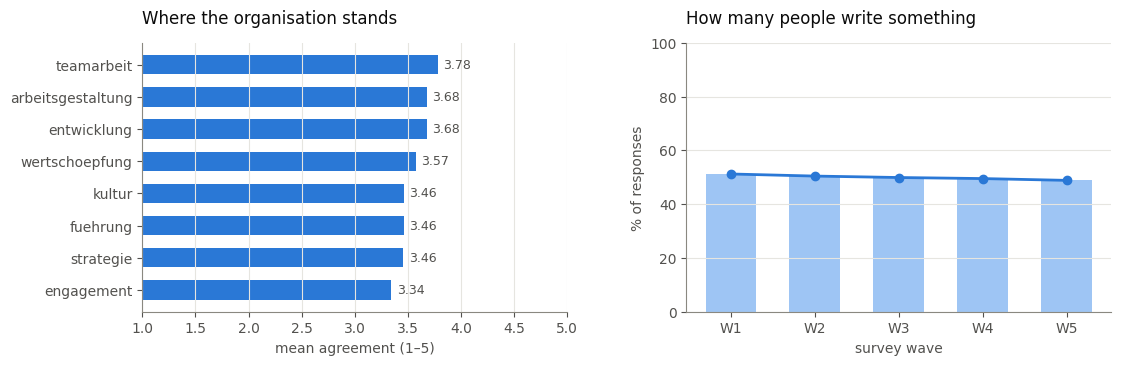

In [6]:
# ============================================================
# Two Pictures
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
fig.subplots_adjust(wspace=0.28, top=0.82, bottom=0.18)

# --- how the dimensions compare
means = data[[f"{name}_score" for name in DIMENSIONS]].mean().sort_values()
labels = [name.replace("_", " ") for name in means.index.str.replace("_score", "")]
axes[0].barh(labels, means.values, color=BLUE, height=0.6)
axes[0].set_xlim(1, 5)
axes[0].grid(axis="y", visible=False)
axes[0].set_xlabel("mean agreement (1–5)")
axes[0].set_title("Where the organisation stands", fontsize=12, loc="left", pad=14)
for y, value in enumerate(means.values):
    axes[0].text(value + 0.05, y, f"{value:.2f}", va="center",
                 color=INK_SOFT, fontsize=9)

# --- who writes a comment
rate = data.groupby("iteration_id")["has_comment"].mean().mul(100)
axes[1].bar(rate.index.astype(str), rate.values, color=BLUE_SOFT, width=0.6)
axes[1].plot(rate.index.astype(str), rate.values, color=BLUE, lw=2, marker="o", ms=6)
axes[1].grid(axis="x", visible=False)
axes[1].set_ylabel("% of responses")
axes[1].set_xlabel("survey wave")
axes[1].set_ylim(0, max(100, rate.max() * 1.2))
axes[1].set_title("How many people write something", fontsize=12, loc="left", pad=14)

plt.show()

The synthetic dataset reflects a plausible organization with generally positive survey results. Teamwork, work design, and development receive the highest ratings, while differences between the thematic dimensions remain moderate overall.

Across all five survey waves, approximately half of all respondents also provided a free-text comment. This stable participation rate ensures sufficient text data for the valence, arousal, and topic modeling analyses presented in the following notebooks.

---

## Step 4 — Hand Over

The cleaned dataset is passed to the next notebook together with all calculated quality indicators. No records are removed at this stage. Instead, the quality flags are retained so that subsequent analyses can decide whether and how they should be taken into account.

In [7]:
# ============================================================
# Export
# ============================================================

data.to_parquet(OUTPUT, index=False)
print(f"written: {OUTPUT.name}   {len(data):,} rows, {len(data.columns)} columns")
print(f"         {OUTPUT.stat().st_size / 1e6:.1f} MB")

written: synthetic_clean.parquet   5,000 rows, 84 columns
         0.7 MB


---

## What This Notebook Establishes

**The survey items provide a usable reference.** The dataset contains 54 survey items on a five-point scale, grouped into eight dimensions, with refusals separated from neutral responses. This matters for what comes next: the validation strategy used throughout the project compares text-derived measures against these survey responses rather than relying on manually annotated comments.

**Roughly half of all respondents write a comment.** Those who do form a self-selected group. This limits every finding drawn from the free-text data and is revisited later when interpreting the results.

**Data quality is visible, but not enforced.** Fast responses and near-uniform answering patterns are flagged for each respondent. The indicators remain available throughout the project so that later analyses can evaluate their impact when required.

---

## Against the Real Data

| | here (synthetic) | real survey |
| :--- | :--- | :--- |
| items | 54 | 54 |
| dimensions | 8 | 8 |
| answer scale | five points plus a refusal option | identical |
| structure of the export | identical | identical |

The structure of the synthetic dataset matches the original survey. Response counts, group sizes, and score levels are not compared here, as those would describe the organisation rather than the dataset itself.

What is compared throughout the notebooks are methodological quality criteria: how well a measure agrees with the survey and how much information a model captures. These findings describe the analytical approach rather than the workforce.